# 00 - Getting Started

This notebook covers:

1. **Legal notice** for the Atari ROM license
2. **Installation** - Conda, pip, and Docker options
3. **Environment checks** - verifying every package (including Atari) is working
4. **Gymnasium tutorial** - the core API you will use in every subsequent notebook

---

## Legal Notice - Atari ROM License

The Atari 2600 game ROMs used by the [Arcade Learning Environment (ALE)](https://github.com/Farama-Foundation/Arcade-Learning-Environment) are **proprietary software** owned by Atari, Inc.  
They are distributed with `ale-py` under a **limited, non-commercial research licence**.

### What the licence allows
- Academic research and personal study
- Non-commercial educational use (courses, tutorials, textbooks)
- Publication of results obtained with these environments

### What the licence prohibits
- Commercial use, sale, or distribution of the ROMs themselves
- Shipping the ROMs as part of a commercial product without a separate Atari licence
- Any use outside the scope of research and education

### Accepting the licence
When you install `ale-py`, the ROMs are bundled but **require explicit acceptance** of the licence terms.  
Run the one-time command below (or pass `--accept-license` / install the helper package shown in the installation section):

```bash
# Accept the Atari ROM licence — required before first use
AutoROM --accept-license
```

Alternatively, install the convenience package that accepts the licence automatically:

```bash
pip install autorom[accept-rom-license]
```

> **Full licence text:** `python -c "import ale_py; print(ale_py.__file__)"` and look for `ROM_LICENCE.md` in the same directory, or visit the [Farama ALE repository](https://github.com/Farama-Foundation/Arcade-Learning-Environment).

---

## 1. Packages

| Package | Purpose |
|---|---|
| [PyTorch](https://pytorch.org/) | Deep learning backend for neural-network policies |
| [Gymnasium](https://gymnasium.farama.org/) | Standard single-agent RL environment API |
| [ale-py](https://github.com/Farama-Foundation/Arcade-Learning-Environment) | Atari 2600 game environments (see legal notice above) |
| [Pygame](https://www.pygame.org/) | Rendering backend used by many environments |
| [PettingZoo](https://pettingzoo.farama.org/) | Multi-agent RL environments |
| [Stable-Baselines3](https://stable-baselines3.readthedocs.io/) | Production-quality single-agent RL algorithms |
| [SB3-Contrib](https://sb3-contrib.readthedocs.io/) | Extra algorithms for Stable-Baselines3 (TQC, TRPO, MaskablePPO, …) |
| [Ray RLlib](https://docs.ray.io/en/latest/rllib/) | Scalable, distributed RL framework |
| [MLflow](https://mlflow.org/) | Experiment tracking, model registry, and run comparison |
| [SuperSuit](https://github.com/Farama-Foundation/SuperSuit) | Environment wrappers for PettingZoo + SB3 |
| [Shimmy](https://github.com/Farama-Foundation/Shimmy) | Gymnasium compatibility shims |
| [TensorBoard](https://www.tensorflow.org/tensorboard) | Training metrics visualisation |

## 2. Installation

Choose **one** of the three options below. All three install the same set of packages.

---

### Option A - Conda (recommended for local development)

The repository ships an `environment.yml` that pins channels and versions for reproducibility.

```bash
# Create and activate the environment (one-time setup)
conda env create -f environment.yml
conda activate rl-python

# Accept the Atari ROM licence (required once per environment)
AutoROM --accept-license
```

**GPU support:** open `environment.yml`, remove the `cpuonly` line, and add `pytorch-cuda=12.1` (or whichever CUDA version matches your driver).

---

### Option B - pip (virtualenv / system Python)

```bash
# Create a virtual environment (recommended)
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate

# GPU only: install PyTorch with CUDA first, then the rest of the requirements
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

pip install -r requirements.txt

# Accept the Atari ROM licence (required once per environment)
AutoROM --accept-license
# - or - install the licence-acceptance helper in one step:
# pip install autorom[accept-rom-license]
```

---

### Option C - Docker (reproducible, isolated, no host dependencies)

The repository includes a `Dockerfile` that builds a self-contained CPU image.

```bash
# Build the image (run once; re-run after requirements.txt changes)
docker build -t rl-lab .

# Launch a Jupyter server inside the container
docker run --rm -it \
  -p 8888:8888 \
  -v "$(pwd)":/workspace \
  rl-lab \
  jupyter notebook --ip=0.0.0.0 --no-browser --allow-root
```

Then open the URL printed in the terminal (e.g. `http://127.0.0.1:8888/...`).

> **GPU inside Docker:** swap the base image in `Dockerfile` to  
> `FROM pytorch/pytorch:2.3.0-cuda12.1-cudnn8-runtime`  
> and add `--gpus all` to the `docker run` command.

---

## 3. Installation Checks

Run every cell in this section. All checks should print **OK**. If any fail, follow the hint printed beneath the error.

In [1]:
import warnings

import ale_py
import cv2
import gymnasium as gym
import matplotlib.pyplot as plt
import minigrid
import mlflow
import numpy as np
import pettingzoo
import pygame
import ray
import sb3_contrib
import shimmy
import stable_baselines3
import supersuit
import tensorboard
import torch
import torchvision
from torch.utils.tensorboard import SummaryWriter

def pprint(statement, max_length=85):
    fmt = int(0.5 * (max_length - len(statement)))
    print(f"{'-'*fmt} {statement} {'-'*fmt}\n")

pprint("All imports successful!")

------------------------------- All imports successful! -------------------------------



Check if CUDA or MPS enables PyTorch is Installed

In [2]:
# Check if CUDA/MPS are available
if torch.cuda.is_available():
    pprint("CUDA is available.")
elif torch.backends.mps.is_available():
    pprint("MPS is available.")
else:
    pprint("CUDA/MPS are not available.")

----------------------------- CUDA/MPS are not available. -----------------------------



Test Gymnasium Environments

In [3]:
env_warning_flag = False

# Classic control environments
try:
    env = gym.make("CartPole-v1")
    obs, _ = env.reset()
    env.close()
except Exception as e:
    raise RuntimeError("Error installing Gymnasium.") from e

# ALE environments
try:
    gym.register_envs(ale_py)
    env = gym.make("ALE/Breakout-v5")
    obs, _ = env.reset()
    env.close()
except Exception:
    env_warning_flag = True
    warnings.warn("ALE environments are not installed.")

# MuJoco environments
try:
    env = gym.make("Reacher-v5")
    obs, _ = env.reset()
    env.close()
except Exception:
    env_warning_flag = True
    warnings.warn("MuJoco environments are not installed.")

# Box2D environments
try:
    env = gym.make("CarRacing-v3")
    obs, _ = env.reset()
    env.close()
except Exception:
    env_warning_flag = True
    warnings.warn("Box2D environments are not installed.")

# MiniGrid environments
try:
    env = gym.make("MiniGrid-Empty-Random-5x5-v0")
    obs, _ = env.reset()
    env.close()
except Exception:
    env_warning_flag = True
    warnings.warn("MiniGrid environments are not installed.")

if not env_warning_flag:
    pprint("All environments are working correctly!")

----------------------- All environments are working correctly! -----------------------



A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


---
## 4. Gymnasium Tutorial

Every algorithm in this repository interacts with environments through the [Gymnasium API](https://gymnasium.farama.org/). This section walks through the core API using **FrozenLake-v1** - a small grid world where an agent must cross a frozen lake without falling into holes.

```
S = start
F = frozen (safe)
H = hole (episode ends, reward = 0)
G = goal (episode ends, reward = 1)
```

FrozenLake is a good first environment because:
- Both observation and action spaces are `Discrete` - easy to inspect and reason about
- Episodes are short, so feedback is fast
- `is_slippery=True` (default) makes the dynamics stochastic - the agent does not always move in the intended direction

### 4.1 Creating an environment

`gym.make(id, render_mode=None)` is the single entry point for every environment.

| `render_mode` | Effect |
|---|---|
| `None` (default) | No rendering - fastest, use for training |
| `"human"` | Opens a window - use for interactive demos |
| `"ansi"` | Returns a text string - useful for grid worlds in notebooks |
| `"rgb_array"` | Returns pixel arrays - use for video recording |

In [4]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")

print("Environment:", env.spec.id)
print()
print("Observation space:", env.observation_space)
print("n (grid cells):", env.observation_space.n)
print("Interpretation: integer 0-15 representing position on the 4x4 grid")
print()
print("Action space:", env.action_space)
print("n (actions):", env.action_space.n)
print("Meanings: 0 = left, 1 = down, 2 = right, 3 = up")

Environment: FrozenLake-v1

Observation space: Discrete(16)
n (grid cells): 16
Interpretation: integer 0-15 representing position on the 4x4 grid

Action space: Discrete(4)
n (actions): 4
Meanings: 0 = left, 1 = down, 2 = right, 3 = up


### 4.2 Resetting an episode

Call `env.reset(seed=...)` at the start of every episode.  
Pass a `seed` to make episodes reproducible.

For FrozenLake the initial observation is always `0` (top-left cell), but seeding matters for the stochastic slip dynamics.

Initial observation (grid cell index): 0


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

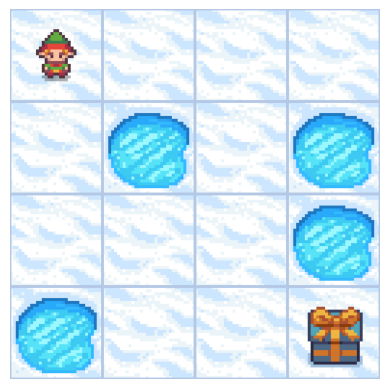

In [5]:
obs, info = env.reset(seed=42)
print(f"Initial observation (grid cell index): {obs}")

frame = env.render()

plt.imshow(frame)
plt.axis('off')

### 4.3 The step loop

```python
obs, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated
```

| Return value | Type | Meaning |
|---|---|---|
| `obs` | int | New grid cell index (0–15) |
| `reward` | float | `1.0` if goal reached, `0.0` otherwise |
| `terminated` | bool | `True` when the agent reaches the goal or falls in a hole |
| `truncated` | bool | `True` when the episode time limit is hit |
| `info` | dict | `{"prob": p}` — transition probability of the step that was taken |

> **Note on `is_slippery`:** when slip is enabled, `info["prob"]` is often `1/3` — the agent only moves in the intended direction with probability 1/3.

> It is also good practice to close the environment as it is important when external software is used.

Step-by-step episode (first 6 steps shown)



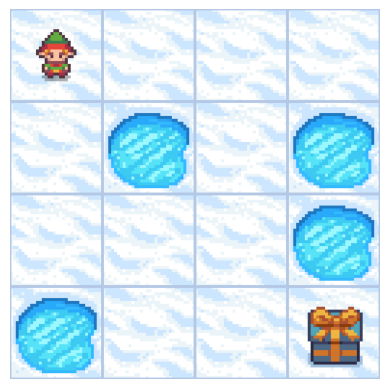

Step 1: action=up, cell=1, reward=0, terminated=False, prob=0.33


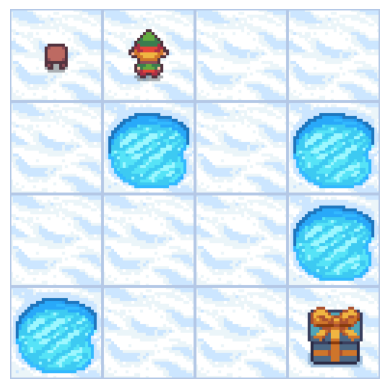

Step 2: action=up, cell=2, reward=0, terminated=False, prob=0.33


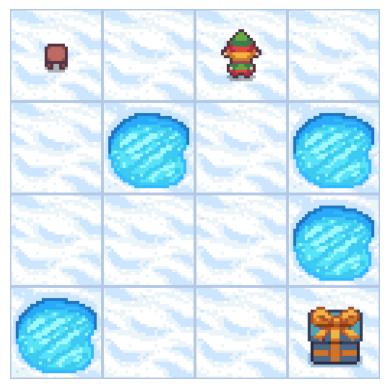

Step 3: action=right, cell=6, reward=0, terminated=False, prob=0.33


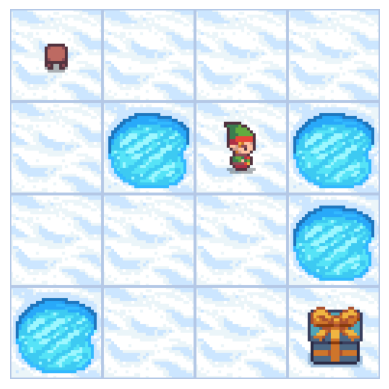

Step 4: action=up, cell=5, reward=0, terminated=True, prob=0.33


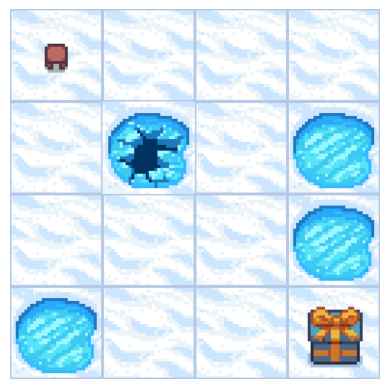

Episode over.


In [6]:
def display_env(env):
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()


obs, info = env.reset(seed=0)
print("Step-by-step episode (first 6 steps shown)\n")
display_env(env)

for step in range(6):
    action = env.action_space.sample()
    action_name = ["left", "down", "right", "up"][action]
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Step {step + 1}: action={action_name}, cell={obs}, reward={reward}, "
          f"terminated={terminated}, prob={info['prob']:.2f}")
    display_env(env)
    if terminated or truncated:
        print("Episode over.")
        break

env.close()

### 4.4 Slippery vs deterministic

By default FrozenLake is stochastic (`is_slippery=True`). Comparing the two variants illustrates how environment dynamics affect a random policy's success rate.

In [7]:
def run_episodes(env, n=1000):
    """Return the fraction of episodes that reached the goal."""
    successes = 0
    for ep in range(n):
        obs, _ = env.reset(seed=ep)
        done = False
        while not done:
            obs, reward, terminated, truncated, _ = env.step(env.action_space.sample())
            done = terminated or truncated
        if reward == 1.0:
            successes += 1
    return successes / n

slippery = gym.make("FrozenLake-v1", is_slippery=True)
deterministic = gym.make("FrozenLake-v1", is_slippery=False)

slip_rate = run_episodes(slippery)
det_rate = run_episodes(deterministic)

slippery.close()
deterministic.close()

print(f"Random policy success rate - slippery: {slip_rate:.1%}")
print(f"Random policy success rate - deterministic: {det_rate:.1%}")

Random policy success rate - slippery: 1.5%
Random policy success rate - deterministic: 1.2%
